# Project 3 — Directional Alpha
## Notebook 03: Model Training

Goal:
Train the first logistic regression model to estimate the probability
that SPY will be up over the next 5 trading days.

**Imports**

In [2]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt


**Rebuild the dataset**

In [3]:
df = pd.read_csv("../../../data/raw/SPY.csv", parse_dates=["Date"])
df = df.set_index("Date")

df.columns = [c.lower() for c in df.columns]

df["ret_1d"] = df["close"].pct_change()
df["fwd_ret_5"] = df["close"].shift(-5) / df["close"] - 1
df["target"] = (df["fwd_ret_5"] > 0).astype(int)

df["ret_5"] = df["close"].pct_change(5)
df["ret_10"] = df["close"].pct_change(10)
df["ret_20"] = df["close"].pct_change(20)

df["ma20"] = df["close"].rolling(20).mean()  # 20 day average
df["ma_dist_20"] = (df["close"] - df["ma20"]) / df["ma20"]

df["rv20"] = df["ret_1d"].rolling(20).std()  # rolling standard deviation of daily returns over the last 20 days

df["vol_ma20"] = df["volume"].rolling(20).mean()  # average trading volume over the last 20 days
df["volume_ratio"] = df["volume"] / df["vol_ma20"]

features = [
    "ret_5",
    "ret_10",
    "ret_20",
    "ma_dist_20",
    "rv20",
    "volume_ratio"
]

df_model = df.dropna(subset=features + ["target"]).copy()

X = df_model[features]
y = df_model["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5269, 6)
y shape: (5269,)


C:\Users\rawls.varghese\AppData\Local\Temp\ipykernel_27976\3480820219.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv("../../../data/raw/SPY.csv", parse_dates=["Date"])


**Train/test split**

In [4]:
split_idx = int(len(df_model) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Train size:", X_train.shape, y_train.shape)
print("Test Size:", X_test.shape, y_test.shape)

Train size: (4215, 6) (4215,)
Test Size: (1054, 6) (1054,)


**Baseline Accuracy**

In [5]:
baseline_pred = np.ones(len(y_test), dtype=int)

baseline_acc = accuracy_score(y_test, baseline_pred)

print("Test Prevalance:", y_test.mean())
print("Baseline accuracy (always predict UP):", baseline_acc)

Test Prevalance: 0.5891840607210627
Baseline accuracy (always predict UP): 0.5891840607210627


**Logistic Regression**

In [6]:
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

**Predictions and Probabilities**

In [7]:
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("First 10 predicted probabilities:")
print(y_prob[:10])

First 10 predicted probabilities:
[0.57881393 0.57488095 0.55791406 0.56126917 0.59679936 0.59802312
 0.60995532 0.63582841 0.64766349 0.62521537]


**Evaluation**

In [8]:
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
brier = brier_score_loss(y_test, y_prob)

print("Baseline accuracy:", round(baseline_acc, 4))
print("Model accuracy:", round(acc, 4))
print("ROC AUC:", round(auc, 4))
print("Brier score:", round(brier, 4))

Baseline accuracy: 0.5892
Model accuracy: 0.5863
ROC AUC: 0.5389
Brier score: 0.2415


Using momentum, mean-reversion, volatility, and volume features, the logistic regression model produces weak predictive signal (ROC AUC ≈ 0.54). While classification accuracy does not exceed the always-up baseline due to the market’s positive drift, the model appears to contain modest ranking ability that may be exploitable through probability-based filtering.

**ROC/AUC Curve**

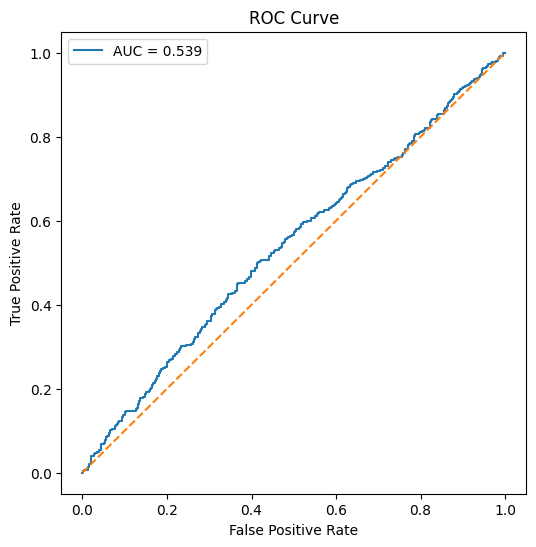

In [27]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig(r"C:\Users\rawls.varghese\quant-lab\experiments\completed\exp_001_dir_alpha_spy_5d\plots\ROC Curve", dpi=300)
plt.show()

ROC is Receiver Operating Characteristic. It is a curve that shows how well a model can seperate two classes. To convert probabilities into predictions, we must choose a threshold. ROC shows how model performance changes as the threshold changes. AUC is area under the curve, it summarizes the ROC curve into one number. In other words, the ROC curve evaluates how well a model ranks positive outcomes above negative ones across all probability thresholds, and the AUC summarizes this ranking ability into a single score.

From the above diagram, the ROC curve shows modest but consistent ranking ability (AUC ≈ 0.539), suggesting the model contains weak directional information even though classification accuracy remains similar to the naive always-up baseline due to the positive drift of equity markets.

**Probability Bin**

In [10]:
prob_df = pd.DataFrame({
    "prob": y_prob,
    "target": y_test,
    "fwd_ret_5": df_model.iloc[split_idx:]["fwd_ret_5"]
})

prob_df["prob_bin"] = pd.qcut(prob_df["prob"], 5)

bin_stats = prob_df.groupby("prob_bin").agg(
    count = ("prob", "size"),
    mean_prob = ("prob", "mean"),
    hit_rate = ("target", "mean"),
    avg_return=("fwd_ret_5", "mean")
)

bin_stats


,count,mean_prob,hit_rate,avg_return
prob_bin,,,,
"(0.475, 0.583]",211,0.561055,0.568720,0.000214
"(0.583, 0.598]",211,0.590943,0.549763,0.000496
"(0.598, 0.608]",210,0.602771,0.566667,0.001981
"(0.608, 0.618]",211,0.612427,0.616114,0.004057
"(0.618, 0.675]",211,0.627625,0.644550,0.004425



The model demonstrates weak but consistent directional ranking ability: higher predicted probabilities correspond to higher hit rates and increasing forward returns, suggesting the signal may be exploitable through probability-based filtering rather than raw classification accuracy.

In [ ]:
from sklearn.metrics import precision_score, recall_score

# convert probability to prediction
prob_df["pred"] = (prob_df["prob"] > 0.5).astype(int)

precision = precision_score(prob_df["target"], prob_df["pred"])  # precision = True Positives / Predicted Positives
recall = recall_score(prob_df["target"], prob_df["pred"])   # Recall = True Positives / Actual Positives

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.5883476599808978
Recall: 0.9919484702093397


In [32]:
prob_df["pred"] = (prob_df["prob"] > 0.5).astype(int)
prob_df["pred"].mean()

np.float64(0.9933586337760911)

**metrics.json**

In [31]:
import json

metrics = {
    "model": "logistic_regression",
    "target": "SPY_5d_direction",
    "auc": auc,
    "accuracy": acc,
    "precision": precision,
    "recall": recall,
    "prevalence": prob_df["target"].mean(),
}

with open(
r"C:\Users\rawls.varghese\quant-lab/experiments/completed/exp_001_dir_alpha_spy_5d/metrics.json",
"w"
) as f:
    json.dump(metrics, f, indent=4)

**Calibration Check**

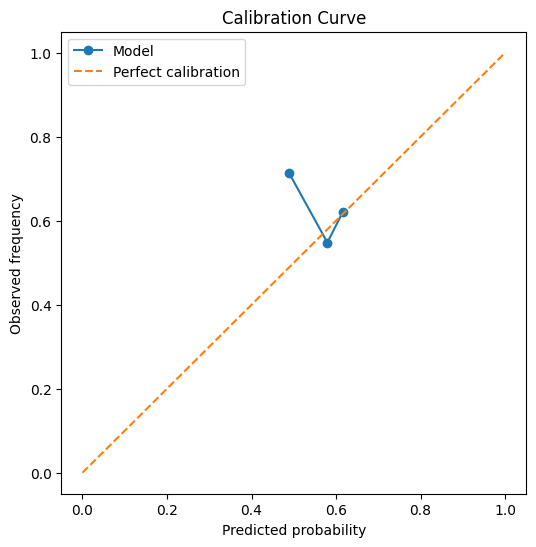

In [26]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0,1],[0,1],"--", label="Perfect calibration")

plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration Curve")
plt.legend()

plt.savefig(r"C:\Users\rawls.varghese\quant-lab\experiments\completed\exp_001_dir_alpha_spy_5d\plots\calibration curve", dpi=300)
plt.show()

The calibration plot suggests the model is somewhat underconfident in parts of the probability range, reinforcing the view that the signal is more useful for ranking and filtering than for precise probability estimation.

In [12]:
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=5)

for p_pred, p_true in zip(prob_pred, prob_true):
    print(f"Predicted: {p_pred:.3f}, Observed: {p_true:.3f}")

Predicted: 0.578, Observed: 0.551
Predicted: 0.615, Observed: 0.620


The calibration results show predicted probabilities are broadly aligned with observed frequencies, indicating reasonable probability calibration despite the compressed probability range typical of weak directional signals in equity markets.

**Predicted Probability - Actual future returns**

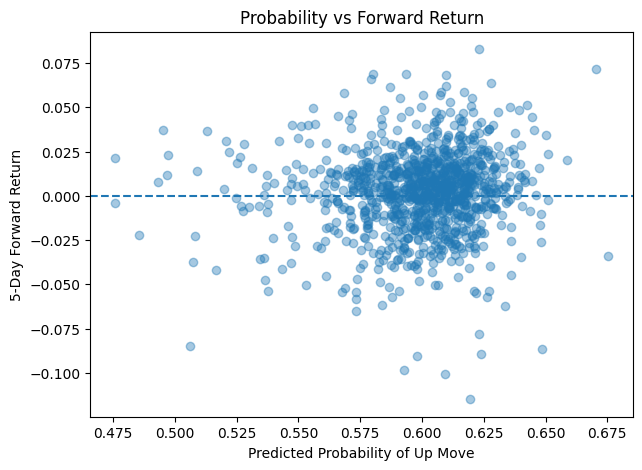

In [15]:

plt.figure(figsize=(7,5))

plt.scatter(prob_df["prob"], prob_df["fwd_ret_5"], alpha=0.4)

plt.xlabel("Predicted Probability of Up Move")
plt.ylabel("5-Day Forward Return")
plt.title("Probability vs Forward Return")

plt.axhline(0, linestyle="--")


plt.show()

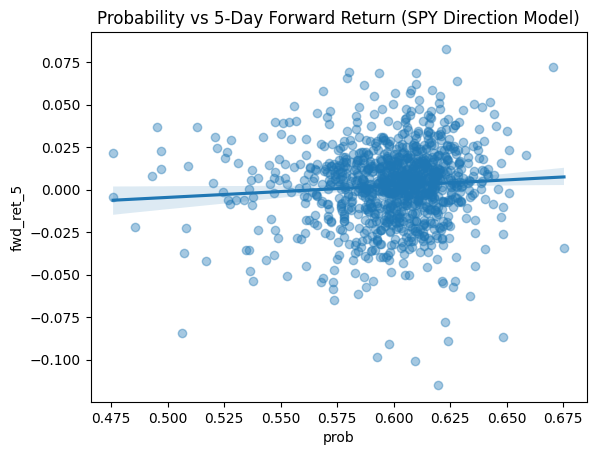

In [25]:
import seaborn as sns

sns.regplot(x=prob_df["prob"], y=prob_df["fwd_ret_5"], scatter_kws={'alpha':0.4})
plt.title("Probability vs 5-Day Forward Return (SPY Direction Model)")
plt.savefig(r"C:\Users\rawls.varghese\quant-lab\experiments\completed\exp_001_dir_alpha_spy_5d\plots\prob_vs_return.png", dpi=300)


The probability–return scatter plot reveals substantial dispersion due to market noise, but the slight upward slope of the fitted regression line suggests that higher predicted probabilities correspond to modestly higher forward returns on average, consistent with the weak directional signal observed in earlier analyses.

In [ ]:
cols = ["prob", "target", "fwd_ret_5"]

prob_df[cols].to_csv(
r"C:\Users\rawls.varghese\quant-lab/experiments/completed/exp_001_dir_alpha_spy_5d/predictions.csv"
)

**Random forest classfier**

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=4,
    random_state=42
)

rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:,1]

from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_prob_rf)

0.5062720115436252

**Project 3 — Directional Alpha Model Summary**


The baseline model achieves an accuracy of ≈0.589, reflecting the positive drift in equity markets where upward moves occur more frequently than downward moves.

The logistic regression model achieves an accuracy of ≈0.586, similar to the baseline, indicating that raw classification accuracy is not an informative metric for this task.

The ROC AUC ≈ 0.539 suggests the model has weak but non-random ranking ability when distinguishing between upward and non-upward moves.

Probability bin analysis shows that higher predicted probabilities correspond to higher average forward returns, indicating that the model captures a modest directional signal.

The calibration analysis indicates that predicted probabilities are broadly consistent with observed outcome frequencies, suggesting reasonable probability calibration.

The probability–return scatter plot shows substantial dispersion due to market noise, but the positive slope of the fitted regression line indicates that higher predicted probabilities are associated with higher average forward returns.

**Coclusion**

The directional model exhibits a weak but consistent predictive signal. While it does not outperform the naive baseline in classification accuracy, the probability outputs appear useful for ranking or filtering trading opportunities, rather than for direct binary prediction